# =========================================================
# IMPACT ANALYSIS - CLEAN FINAL WORKFLOW
# =========================================================

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

In [48]:
# =========================================================
# 1. LOAD DATA
# =========================================================

baseline_path = r"C:\Users\Avikansh\Downloads\2026_Analysis\Baseline_Final.xlsx"
midline_path  = r"C:\Users\Avikansh\Downloads\2026_Analysis\Sironj_Midline_Final.xlsx"

baseline_df = pd.read_excel(baseline_path)
midline_df  = pd.read_excel(midline_path)

print("Baseline shape:", baseline_df.shape)
print("Midline shape:", midline_df.shape)

Baseline shape: (415, 36)
Midline shape: (415, 36)


In [49]:
# =========================================================
# 2. STANDARDIZE / CLEAN DATA
# =========================================================

def standardize_df(df):
    df = df.copy()

    # Clean column names
    df.columns = df.columns.str.strip().str.replace(" ", "_", regex=False)

    # Clean important text columns
    text_cols = ['Student_Name', 'School_Name', 'Group', 'Grade', 'Gender_(M/F)']
    for col in text_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip()

    # Standardize group labels
    if 'Group' in df.columns:
        group_map = {
            'treatment': 'Treatment',
            'intervention': 'Treatment',
            'control': 'Control',
            'reference': 'Control',
            'general': 'General',
            'demo': 'General'
        }
        df['Group'] = df['Group'].str.lower().map(group_map).fillna(df['Group'])

         # Standardize gender
    if 'Gender_(M/F)' in df.columns:
        df['Gender_(M/F)'] = df['Gender_(M/F)'].str.upper().replace({
            'MALE': 'M',
            'FEMALE': 'F'
        })

    # Convert score columns to numeric
    score_cols = ['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated']
    for col in score_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    return df


baseline_df = standardize_df(baseline_df)
midline_df = standardize_df(midline_df)


In [50]:
# =========================================================
# 3. BASIC DATA CHECKS
# =========================================================

print("\nMissing values in baseline:")
print(baseline_df.isnull().sum())

print("\nMissing values in midline:")
print(midline_df.isnull().sum())

print("\nBaseline duplicate rows:", baseline_df.duplicated().sum())
print("Midline duplicate rows:", midline_df.duplicated().sum())

print("\nBaseline columns:")
print(baseline_df.columns.tolist())

print("\nMidline columns:")
print(midline_df.columns.tolist())


Missing values in baseline:
Sno                    40
Student_Name            0
Grade                   0
Group                   0
School_Name             0
Gender_(M/F)            0
literacy_tercile       33
terciles               33
Hindi_Reading_1        40
Hindi_Reading_2        40
Hindi_Reading_3        40
Hindi_Reading_4        40
Hindi_Reading_5        40
Hindi_Reading_6        40
Hindi_Reading_7        40
Hindi_Writing_1        40
Hindi_Writing_2        40
Hindi_Writing_3        40
Hindi_Writing_4        40
Numeracy_Q1            40
Numeracy_Q2            40
Numeracy_Q3            40
Numeracy_Q4            40
Numeracy_Q5            40
Numeracy_Q6            40
Numeracy_Q7            40
Numeracy_Q8            40
Numeracy_Q9            40
Numeracy_Q10           40
Numeracy_Q11           40
Reading_Calculated      0
Writing_Calculated      0
Numeracy_Calculated     0
Reading_Calc_%          0
Writing_Calc_%          0
Numeracy_Calc_%         0
dtype: int64

Missing values in mid

In [51]:
# =========================================================
# 5. FEATURE ENGINEERING
# =========================================================

baseline_df['Overall_Score'] = (
    baseline_df['Reading_Calculated'] +
    baseline_df['Writing_Calculated'] +
    baseline_df['Numeracy_Calculated']
)

midline_df['Overall_Score'] = (
    midline_df['Reading_Calculated'] +
    midline_df['Writing_Calculated'] +
    midline_df['Numeracy_Calculated']
)

# Terciles
baseline_df['Overall_Tercile'] = pd.qcut(
    baseline_df['Overall_Score'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

midline_df['Overall_Tercile'] = pd.qcut(
    midline_df['Overall_Score'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

# Final business-friendly labels
tercile_mapping = {
    'Low': 'Below Basic',
    'Medium': 'Basic',
    'High': 'Proficient'
}

baseline_df['Overall_Tercile'] = baseline_df['Overall_Tercile'].astype(str).str.strip().str.title()
midline_df['Overall_Tercile'] = midline_df['Overall_Tercile'].astype(str).str.strip().str.title()

baseline_df['Tercile_Label'] = baseline_df['Overall_Tercile'].map(tercile_mapping)
midline_df['Tercile_Label'] = midline_df['Overall_Tercile'].map(tercile_mapping)


In [52]:
# =========================================================
# 6. DESCRIPTIVE SUMMARY
# =========================================================

baseline_summary = baseline_df[
    ['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated', 'Overall_Score']
].describe().T

midline_summary = midline_df[
    ['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated', 'Overall_Score']
].describe().T

print("\nBaseline Summary")
print(baseline_summary)

print("\nMidline Summary")
print(midline_summary)

print("\nBaseline Group Distribution")
print(baseline_df['Group'].value_counts(dropna=False))

print("\nMidline Group Distribution")
print(midline_df['Group'].value_counts(dropna=False))

print("\nBaseline Tercile Distribution")
print(baseline_df['Tercile_Label'].value_counts(dropna=False))

print("\nMidline Tercile Distribution")
print(midline_df['Tercile_Label'].value_counts(dropna=False))



Baseline Summary
                     count       mean        std  min   25%   50%   75%   max
Reading_Calculated   415.0  12.583133   7.877823  0.0   7.0  13.0  19.0  27.0
Writing_Calculated   415.0   4.159036   4.831835  0.0   0.0   2.0   8.0  17.0
Numeracy_Calculated  415.0  11.703614   8.251562  0.0   6.0  11.0  17.0  35.0
Overall_Score        415.0  28.445783  19.078564  0.0  15.0  26.0  42.5  79.0

Midline Summary
                     count       mean        std  min  25%   50%   75%   max
Reading_Calculated   415.0  14.383133  10.286251  0.0  0.0  17.0  24.0  28.0
Writing_Calculated   415.0   5.467470   5.640029  0.0  0.0   4.0  10.0  17.0
Numeracy_Calculated  415.0  14.166265  10.979287  0.0  0.0  15.0  23.0  36.0
Overall_Score        415.0  34.016867  25.146954  0.0  0.0  39.0  55.0  79.0

Baseline Group Distribution
Group
Control      228
Treatment    147
nan           40
Name: count, dtype: int64

Midline Group Distribution
Group
Control      169
Treatment    131
nan       

In [53]:
# =========================================================
# 7. OVERALL COMPARISON TABLE
# =========================================================

overall_compare = pd.DataFrame({
    'Baseline': baseline_df[['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated', 'Overall_Score']].mean(),
    'Midline': midline_df[['Reading_Calculated', 'Writing_Calculated', 'Numeracy_Calculated', 'Overall_Score']].mean()
}).round(2)

print("\nOverall Comparison")
print(overall_compare)


Overall Comparison
                     Baseline  Midline
Reading_Calculated      12.58    14.38
Writing_Calculated       4.16     5.47
Numeracy_Calculated     11.70    14.17
Overall_Score           28.45    34.02


In [54]:
overall_compare.reset_index()


,index,Baseline,Midline
0,Reading_Calculated,12.58,14.38
1,Writing_Calculated,4.16,5.47
2,Numeracy_Calculated,11.70,14.17
3,Overall_Score,28.45,34.02


In [55]:
overall_compare_plot = overall_compare.reset_index().melt(
    id_vars='index',
    var_name='Stage',
    value_name='Average_Score'
)
overall_compare_plot

,index,Stage,Average_Score
0,Reading_Calculated,Baseline,12.58
1,Writing_Calculated,Baseline,4.16
2,Numeracy_Calculated,Baseline,11.70
3,Overall_Score,Baseline,28.45
4,Reading_Calculated,Midline,14.38
5,Writing_Calculated,Midline,5.47
6,Numeracy_Calculated,Midline,14.17
7,Overall_Score,Midline,34.02


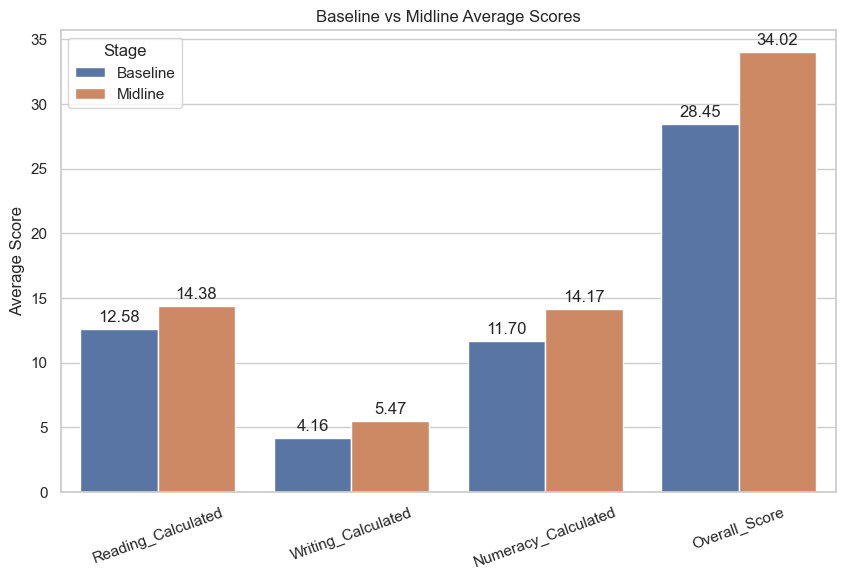

In [56]:
# =========================================================
# 8. OVERALL VISUALS
# =========================================================

# 8.1 Baseline vs Midline Average Scores
overall_compare_plot = overall_compare.reset_index().melt(
    id_vars='index',
    var_name='Stage',
    value_name='Average_Score'
)
overall_compare_plot.rename(columns={'index': 'Metric'}, inplace=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=overall_compare_plot, x='Metric', y='Average_Score', hue='Stage')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title("Baseline vs Midline Average Scores")
plt.xticks(rotation=20)
plt.ylabel("Average Score")
plt.xlabel("")
plt.show()

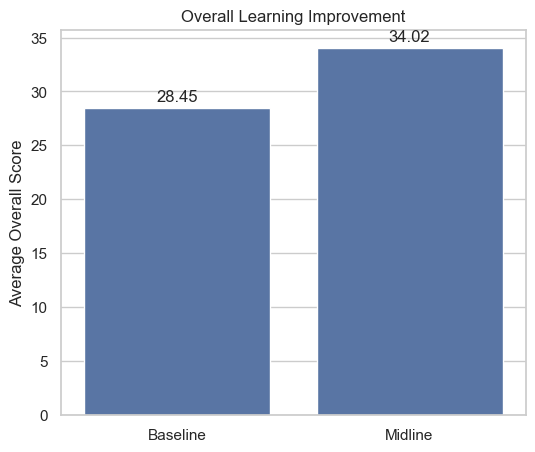

In [57]:
# 8.2 Overall Learning Improvement
overall_only = pd.DataFrame({
    'Stage': ['Baseline', 'Midline'],
    'Overall_Score': [
        baseline_df['Overall_Score'].mean(),
        midline_df['Overall_Score'].mean()
    ]
})

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=overall_only, x='Stage', y='Overall_Score')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title("Overall Learning Improvement")
plt.ylabel("Average Overall Score")
plt.xlabel("")
plt.show()


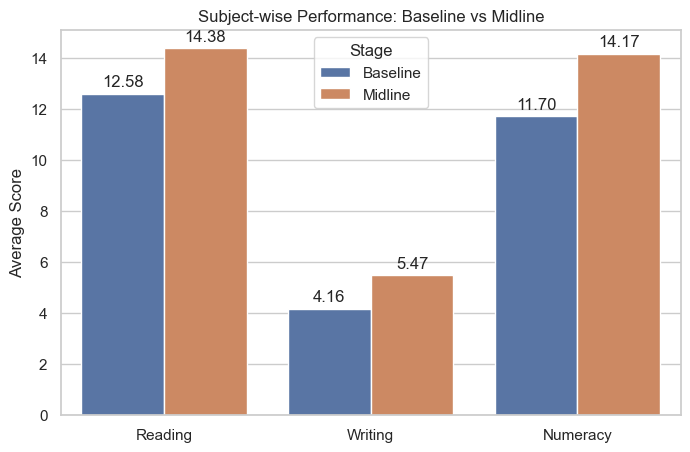

In [58]:
# 8.3 Subject-wise Performance
subject_plot = pd.DataFrame({
    'Subject': ['Reading', 'Writing', 'Numeracy'],
    'Baseline': [
        baseline_df['Reading_Calculated'].mean(),
        baseline_df['Writing_Calculated'].mean(),
        baseline_df['Numeracy_Calculated'].mean()
    ],
    'Midline': [
        midline_df['Reading_Calculated'].mean(),
        midline_df['Writing_Calculated'].mean(),
        midline_df['Numeracy_Calculated'].mean()
    ]
})

subject_plot_melted = subject_plot.melt(
    id_vars='Subject',
    var_name='Stage',
    value_name='Average_Score'
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=subject_plot_melted, x='Subject', y='Average_Score', hue='Stage')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title("Subject-wise Performance: Baseline vs Midline")
plt.ylabel("Average Score")
plt.xlabel("")
plt.show()


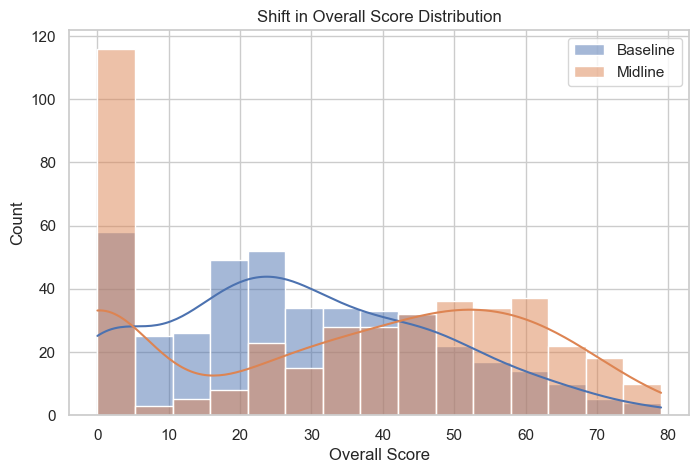

In [59]:
# 8.4 Shift in Overall Score Distribution
plt.figure(figsize=(8, 5))
sns.histplot(baseline_df['Overall_Score'], kde=True, label='Baseline', bins=15)
sns.histplot(midline_df['Overall_Score'], kde=True, label='Midline', bins=15)
plt.legend()
plt.title("Shift in Overall Score Distribution")
plt.xlabel("Overall Score")
plt.ylabel("Count")
plt.show()

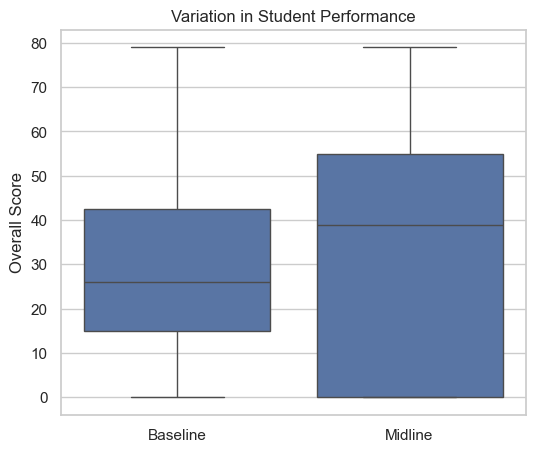

In [60]:
# 8.5 Variation in Student Performance
score_dist = pd.concat([
    baseline_df[['Overall_Score']].assign(Stage='Baseline'),
    midline_df[['Overall_Score']].assign(Stage='Midline')
], ignore_index=True)

plt.figure(figsize=(6, 5))
sns.boxplot(data=score_dist, x='Stage', y='Overall_Score')
plt.title("Variation in Student Performance")
plt.xlabel("")
plt.ylabel("Overall Score")
plt.show()

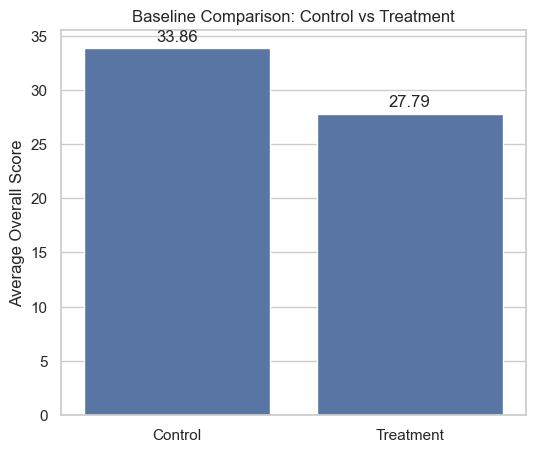

In [61]:
# =========================================================
# 9. GROUP-WISE ANALYSIS
# =========================================================

# 9.1 Baseline Comparison: Control vs Treatment
baseline_group_only = (
    baseline_df[baseline_df['Group'].isin(['Control', 'Treatment'])]
    .groupby('Group', as_index=False)['Overall_Score']
    .mean()
)

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=baseline_group_only, x='Group', y='Overall_Score')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title("Baseline Comparison: Control vs Treatment")
plt.ylabel("Average Overall Score")
plt.xlabel("")
plt.show()

# =========================================================




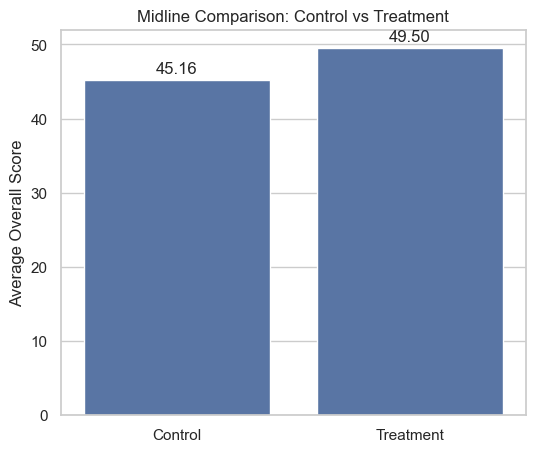

In [62]:
# 9.2 Midline Comparison: Control vs Treatment
midline_group_only = (
    midline_df[midline_df['Group'].isin(['Control', 'Treatment'])]
    .groupby('Group', as_index=False)['Overall_Score']
    .mean()
)

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=midline_group_only, x='Group', y='Overall_Score')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title("Midline Comparison: Control vs Treatment")
plt.ylabel("Average Overall Score")
plt.xlabel("")
plt.show()

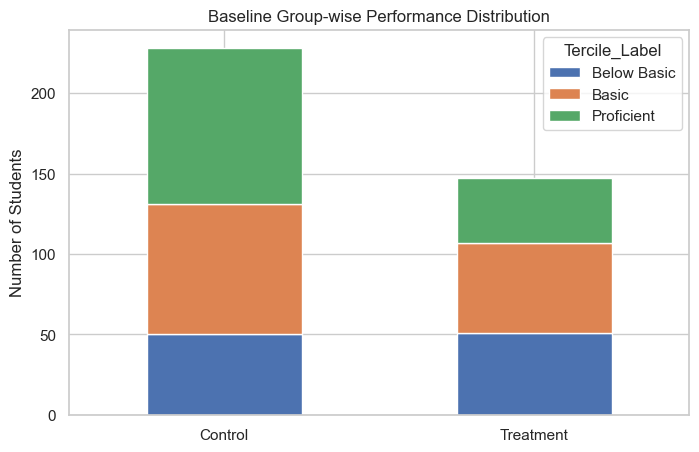

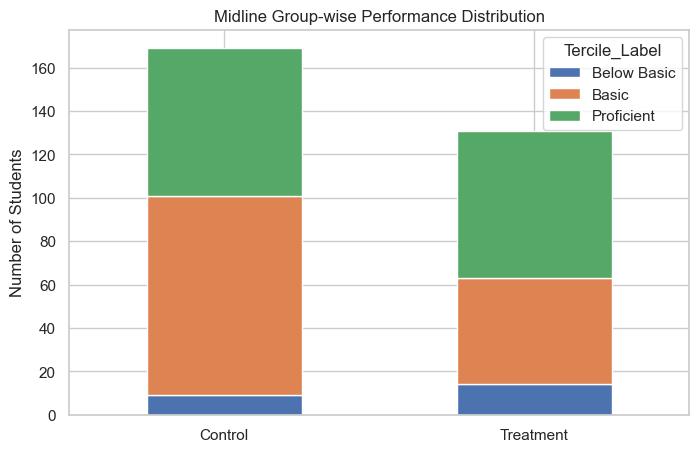

In [63]:
# 9.3 Group-wise Tercile Distribution (Counts)
baseline_tercile_group = pd.crosstab(
    baseline_df['Group'],
    baseline_df['Tercile_Label']
)

midline_tercile_group = pd.crosstab(
    midline_df['Group'],
    midline_df['Tercile_Label']
)

desired_order = ['Below Basic', 'Basic', 'Proficient']

baseline_tercile_group = baseline_tercile_group.reindex(
    index=['Control', 'Treatment'],
    columns=desired_order,
    fill_value=0
)

midline_tercile_group = midline_tercile_group.reindex(
    index=['Control', 'Treatment'],
    columns=desired_order,
    fill_value=0
)

baseline_tercile_group.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title("Baseline Group-wise Performance Distribution")
plt.ylabel("Number of Students")
plt.xlabel("")
plt.xticks(rotation=0)
plt.show()

midline_tercile_group.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title("Midline Group-wise Performance Distribution")
plt.ylabel("Number of Students")
plt.xlabel("")
plt.xticks(rotation=0)
plt.show()


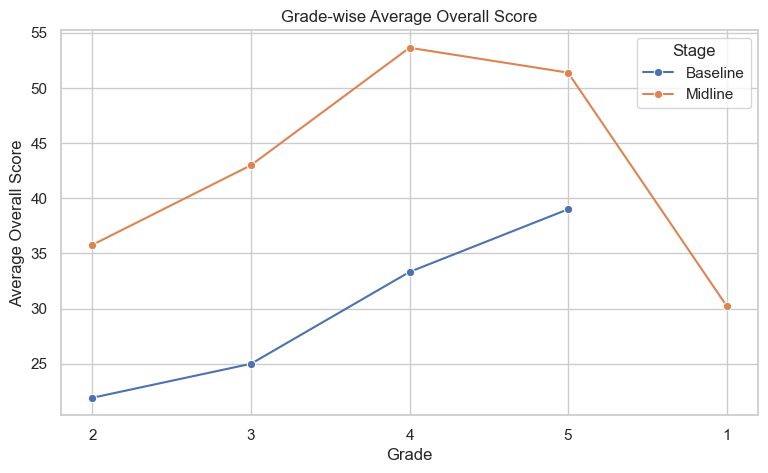

In [67]:
# =========================================================
# 10. GRADE-WISE ANALYSIS
# =========================================================

baseline_grade = baseline_df.groupby('Grade', as_index=False)['Overall_Score'].mean()
baseline_grade['Stage'] = 'Baseline'

midline_grade = midline_df.groupby('Grade', as_index=False)['Overall_Score'].mean()
midline_grade['Stage'] = 'Midline'

grade_plot = pd.concat([baseline_grade, midline_grade], ignore_index=True)
grade_plot = grade_plot[grade_plot['Grade'].notna()]
grade_plot = grade_plot[grade_plot['Grade'].astype(str).str.lower() != 'nan']

plt.figure(figsize=(9, 5))
sns.lineplot(data=grade_plot, x='Grade', y='Overall_Score', hue='Stage', marker='o')
plt.title("Grade-wise Average Overall Score")
plt.ylabel("Average Overall Score")
plt.xlabel("Grade")
plt.show()


Baseline Gender Distribution
Gender_(M/F)
F      214
M      161
NAN     40
Name: count, dtype: int64

Midline Gender Distribution
Gender_(M/F)
F      178
M      120
NAN    116
L        1
Name: count, dtype: int64


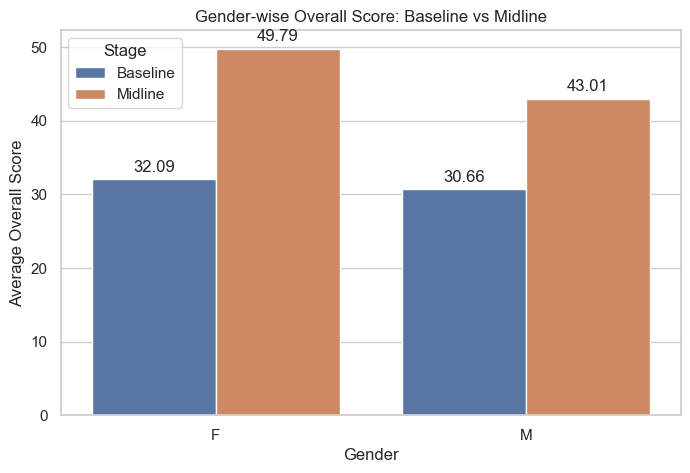

In [65]:
# =========================================================
# 11. GENDER-WISE ANALYSIS
# =========================================================

print("\nBaseline Gender Distribution")
print(baseline_df['Gender_(M/F)'].value_counts(dropna=False))

print("\nMidline Gender Distribution")
print(midline_df['Gender_(M/F)'].value_counts(dropna=False))

baseline_gender = (
    baseline_df[baseline_df['Gender_(M/F)'].isin(['M', 'F'])]
    .groupby('Gender_(M/F)', as_index=False)['Overall_Score']
    .mean()
)
baseline_gender['Stage'] = 'Baseline'

midline_gender = (
    midline_df[midline_df['Gender_(M/F)'].isin(['M', 'F'])]
    .groupby('Gender_(M/F)', as_index=False)['Overall_Score']
    .mean()
)
midline_gender['Stage'] = 'Midline'

gender_plot = pd.concat([baseline_gender, midline_gender], ignore_index=True)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=gender_plot, x='Gender_(M/F)', y='Overall_Score', hue='Stage')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title("Gender-wise Overall Score: Baseline vs Midline")
plt.xlabel("Gender")
plt.ylabel("Average Overall Score")
plt.show()


In [66]:
# 12. MATCHED STUDENTS IMPACT ANALYSIS
# =========================================================

# Create merge ID
for d in [baseline_df, midline_df]:
    d['Student_Name'] = d['Student_Name'].astype(str).str.strip().str.lower()
    d['School_Name'] = d['School_Name'].astype(str).str.strip().str.lower()
    d['Grade'] = d['Grade'].astype(str).str.strip()

    d['id'] = (
        d['Student_Name'] + "_" +
        d['School_Name'] + "_" +
        d['Grade']
    )

# Remove duplicates before merge
baseline_match = baseline_df.drop_duplicates(subset='id').copy()
midline_match = midline_df.drop_duplicates(subset='id').copy()

print("\nUnique baseline IDs:", baseline_match['id'].nunique())
print("Unique midline IDs:", midline_match['id'].nunique())

# Merge matched children
impact_df = pd.merge(
    baseline_match,
    midline_match,
    on='id',
    suffixes=('_base', '_mid')
)

print("Matched children:", impact_df.shape[0])

# Improvement columns
impact_df['Reading_Improvement'] = impact_df['Reading_Calculated_mid'] - impact_df['Reading_Calculated_base']
impact_df['Writing_Improvement'] = impact_df['Writing_Calculated_mid'] - impact_df['Writing_Calculated_base']
impact_df['Numeracy_Improvement'] = impact_df['Numeracy_Calculated_mid'] - impact_df['Numeracy_Calculated_base']

impact_df['Overall_Improvement'] = (
    impact_df['Reading_Improvement'] +
    impact_df['Writing_Improvement'] +
    impact_df['Numeracy_Improvement']
)

impact_summary = impact_df[
    ['Reading_Improvement', 'Writing_Improvement', 'Numeracy_Improvement', 'Overall_Improvement']
].describe().T

print("\nImpact Summary")
print(impact_summary)

impact_group = impact_df.groupby('Group_base')[
    ['Reading_Improvement', 'Writing_Improvement', 'Numeracy_Improvement', 'Overall_Improvement']
].mean().round(2)

print("\nGroup-wise Impact")
print(impact_group)



Unique baseline IDs: 375
Unique midline IDs: 297
Matched children: 62

Impact Summary
                      count       mean        std   min   25%   50%    75%  \
Reading_Improvement    62.0   5.129032   6.812438 -14.0  1.00   4.5  10.00   
Writing_Improvement    62.0   3.016129   4.653544  -9.0  0.00   3.5   5.75   
Numeracy_Improvement   62.0   5.548387   8.356165 -17.0  1.00   5.5  10.00   
Overall_Improvement    62.0  13.693548  16.197135 -35.0  2.75  15.5  23.75   

                       max  
Reading_Improvement   21.0  
Writing_Improvement   15.0  
Numeracy_Improvement  26.0  
Overall_Improvement   56.0  

Group-wise Impact
            Reading_Improvement  Writing_Improvement  Numeracy_Improvement  \
Group_base                                                                   
Control                    4.22                 2.41                  3.41   
Treatment                  6.31                 3.79                  8.10   
nan                        0.00               

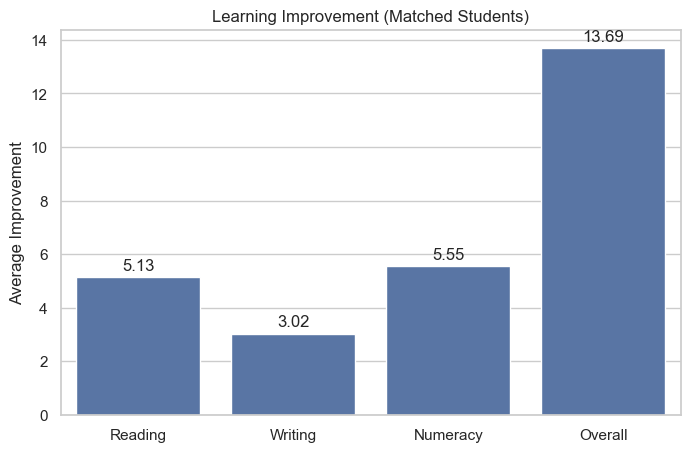

In [67]:
# =========================================================
# 13. IMPACT VISUALS
# =========================================================

# 13.1 Learning Improvement (Matched Students)
matched_subject_improvement = pd.DataFrame({
    'Metric': ['Reading', 'Writing', 'Numeracy', 'Overall'],
    'Improvement': [
        impact_df['Reading_Improvement'].mean(),
        impact_df['Writing_Improvement'].mean(),
        impact_df['Numeracy_Improvement'].mean(),
        impact_df['Overall_Improvement'].mean()
    ]
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=matched_subject_improvement, x='Metric', y='Improvement')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title("Learning Improvement (Matched Students)")
plt.ylabel("Average Improvement")
plt.xlabel("")
plt.show()

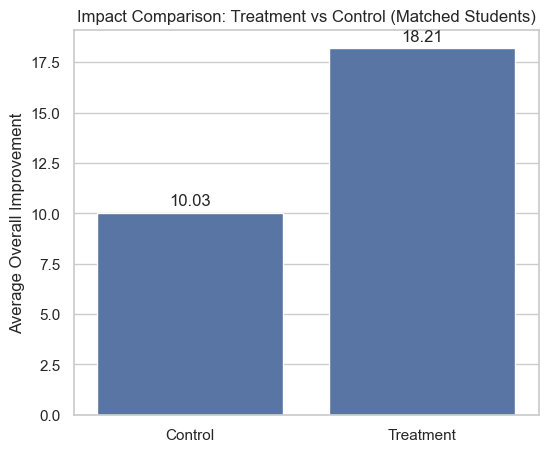

In [68]:
# 13.2 Impact Comparison: Treatment vs Control (Matched Students)
impact_group_plot = (
    impact_df[impact_df['Group_base'].isin(['Control', 'Treatment'])]
    .groupby('Group_base', as_index=False)['Overall_Improvement']
    .mean()
)

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=impact_group_plot, x='Group_base', y='Overall_Improvement')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title("Impact Comparison: Treatment vs Control (Matched Students)")
plt.ylabel("Average Overall Improvement")
plt.xlabel("")
plt.show()

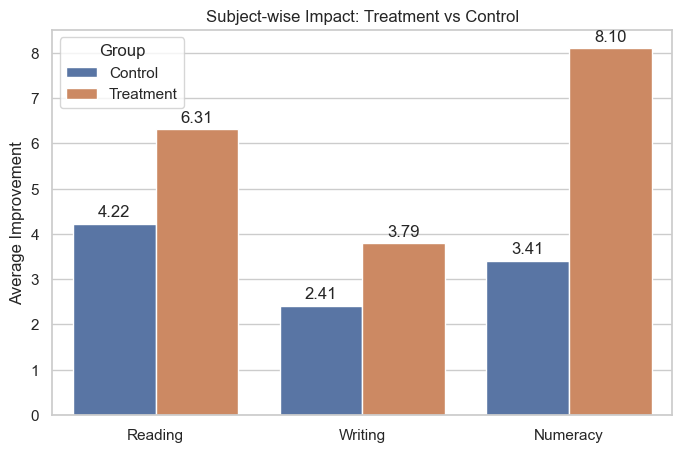

In [69]:
# 13.3 Subject-wise Impact: Treatment vs Control (Calculated, not hardcoded)
impact_subject_plot = (
    impact_df[impact_df['Group_base'].isin(['Control', 'Treatment'])]
    .groupby('Group_base')[['Reading_Improvement', 'Writing_Improvement', 'Numeracy_Improvement']]
    .mean()
    .reset_index()
    .rename(columns={
        'Group_base': 'Group',
        'Reading_Improvement': 'Reading',
        'Writing_Improvement': 'Writing',
        'Numeracy_Improvement': 'Numeracy'
    })
)

impact_subject_melted = impact_subject_plot.melt(
    id_vars='Group',
    var_name='Subject',
    value_name='Improvement'
)

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=impact_subject_melted, x='Subject', y='Improvement', hue='Group')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title("Subject-wise Impact: Treatment vs Control")
plt.ylabel("Average Improvement")
plt.xlabel("")
plt.show()


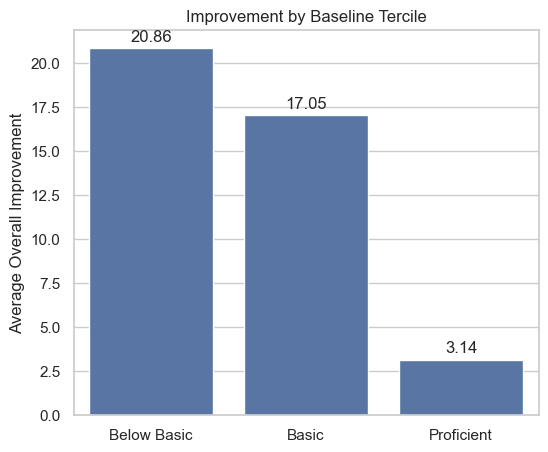

In [70]:
# 13.4 Improvement by Baseline Tercile
impact_df['Overall_Score_base'] = (
    impact_df['Reading_Calculated_base'] +
    impact_df['Writing_Calculated_base'] +
    impact_df['Numeracy_Calculated_base']
)

impact_df['Baseline_Tercile'] = pd.qcut(
    impact_df['Overall_Score_base'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)

impact_df['Baseline_Tercile_Label'] = impact_df['Baseline_Tercile'].astype(str).map(tercile_mapping)

tercile_impact_plot = (
    impact_df.groupby('Baseline_Tercile_Label', as_index=False)['Overall_Improvement']
    .mean()
)

tercile_impact_plot['Baseline_Tercile_Label'] = pd.Categorical(
    tercile_impact_plot['Baseline_Tercile_Label'],
    categories=desired_order,
    ordered=True
)
tercile_impact_plot = tercile_impact_plot.sort_values('Baseline_Tercile_Label')

plt.figure(figsize=(6, 5))
ax = sns.barplot(data=tercile_impact_plot, x='Baseline_Tercile_Label', y='Overall_Improvement')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title("Improvement by Baseline Tercile")
plt.ylabel("Average Overall Improvement")
plt.xlabel("")
plt.show()


In [71]:
# =========================================================
# 14. T-TEST
# =========================================================

treatment = impact_df[impact_df['Group_base'] == 'Treatment']['Overall_Improvement'].dropna()
control = impact_df[impact_df['Group_base'] == 'Control']['Overall_Improvement'].dropna()

t_stat, p_value = ttest_ind(treatment, control, equal_var=False)

print("\nT-test Result")
print("T-statistic:", t_stat)
print("P-value:", p_value)


T-test Result
T-statistic: 2.024001821900119
P-value: 0.047505704282082534


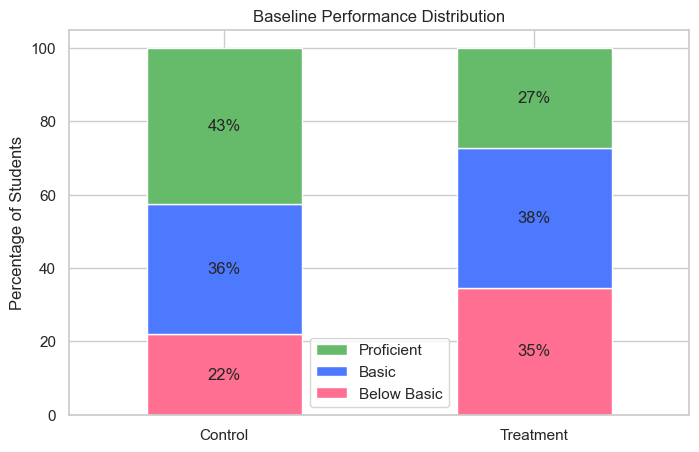

In [72]:
# =========================================================
# 15. FINAL TERCILE PERCENTAGE CHARTS
# =========================================================

color_map = {
    'Below Basic': '#ff6f91',
    'Basic': '#4d79ff',
    'Proficient': '#66bb6a'
}

# Baseline
clean_baseline = baseline_df[
    baseline_df['Group'].isin(['Control', 'Treatment']) &
    baseline_df['Tercile_Label'].notna()
]

baseline_tercile_pct = pd.crosstab(
    clean_baseline['Group'],
    clean_baseline['Tercile_Label'],
    normalize='index'
) * 100

baseline_tercile_pct = baseline_tercile_pct.reindex(
    index=['Control', 'Treatment'],
    columns=desired_order,
    fill_value=0
)

colors = [color_map[col] for col in baseline_tercile_pct.columns]

ax = baseline_tercile_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=colors
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center')

plt.title("Baseline Performance Distribution")
plt.ylabel("Percentage of Students")
plt.xlabel("")
plt.xticks(rotation=0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="")
plt.show()


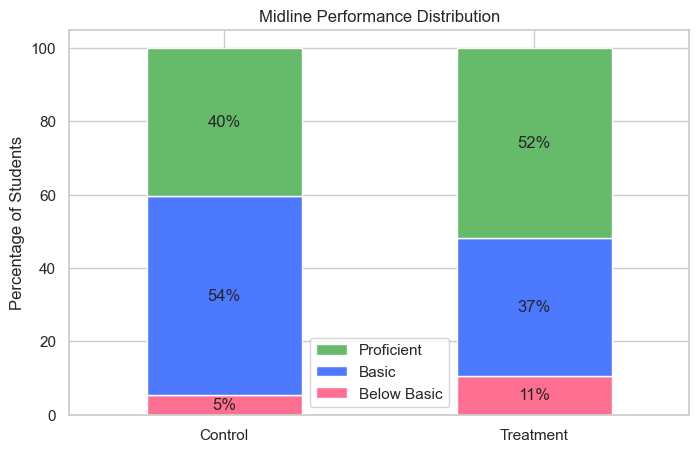

In [75]:
# Midline
clean_midline = midline_df[
    midline_df['Group'].isin(['Control', 'Treatment']) &
    midline_df['Tercile_Label'].notna()
]

midline_tercile_pct = pd.crosstab(
    clean_midline['Group'],
    clean_midline['Tercile_Label'],
    normalize='index'
) * 100

midline_tercile_pct = midline_tercile_pct.reindex(
    index=['Control', 'Treatment'],
    columns=desired_order,
    fill_value=0
)

colors = [color_map[col] for col in midline_tercile_pct.columns]

ax = midline_tercile_pct.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5),
    color=colors
)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center')

plt.title("Midline Performance Distribution")
plt.ylabel("Percentage of Students")
plt.xlabel("")
plt.xticks(rotation=0)

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[::-1], labels[::-1], title="")
plt.show()


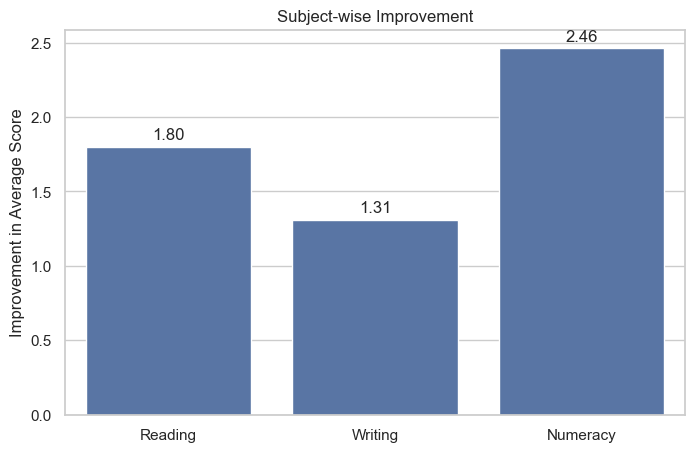

In [74]:
# =========================================================
# 16. SUBJECT-WISE IMPROVEMENT
# =========================================================

subject_improvement = pd.DataFrame({
    'Subject': ['Reading', 'Writing', 'Numeracy'],
    'Improvement': [
        midline_df['Reading_Calculated'].mean() - baseline_df['Reading_Calculated'].mean(),
        midline_df['Writing_Calculated'].mean() - baseline_df['Writing_Calculated'].mean(),
        midline_df['Numeracy_Calculated'].mean() - baseline_df['Numeracy_Calculated'].mean()
    ]
})

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=subject_improvement, x='Subject', y='Improvement')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3)
plt.title("Subject-wise Improvement")
plt.ylabel("Improvement in Average Score")
plt.xlabel("")
plt.show()


In [75]:
# 17. FINAL KEY NUMBERS
# =========================================================

print("\nFinal Overall Mean Comparison")
print(pd.DataFrame({
    'Baseline_Overall_Mean': [baseline_df['Overall_Score'].mean()],
    'Midline_Overall_Mean': [midline_df['Overall_Score'].mean()],
    'Overall_Improvement': [midline_df['Overall_Score'].mean() - baseline_df['Overall_Score'].mean()]
}).round(2))

print("\nDone: Clean impact analysis workflow completed.")


Final Overall Mean Comparison
   Baseline_Overall_Mean  Midline_Overall_Mean  Overall_Improvement
0                  28.45                 34.02                 5.57

Done: Clean impact analysis workflow completed.


# Marks Analysis

In [78]:
# baseline_df.columns.tolist()

In [79]:
reading_cols = [
    'Hindi_Reading_1', 'Hindi_Reading_2', 'Hindi_Reading_3',
    'Hindi_Reading_4', 'Hindi_Reading_5', 'Hindi_Reading_6',
    'Hindi_Reading_7'
]

writing_cols = [
    'Hindi_Writing_1', 'Hindi_Writing_2',
    'Hindi_Writing_3', 'Hindi_Writing_4'
]

numeracy_cols = [
    'Numeracy_Q1', 'Numeracy_Q2', 'Numeracy_Q3', 'Numeracy_Q4',
    'Numeracy_Q5', 'Numeracy_Q6', 'Numeracy_Q7', 'Numeracy_Q8',
    'Numeracy_Q9', 'Numeracy_Q10', 'Numeracy_Q11'
]

all_question_cols = reading_cols + writing_cols + numeracy_cols

print(all_question_cols)
print([col for col in all_question_cols if col not in baseline_df.columns])
print([col for col in all_question_cols if col not in midline_df.columns])


['Hindi_Reading_1', 'Hindi_Reading_2', 'Hindi_Reading_3', 'Hindi_Reading_4', 'Hindi_Reading_5', 'Hindi_Reading_6', 'Hindi_Reading_7', 'Hindi_Writing_1', 'Hindi_Writing_2', 'Hindi_Writing_3', 'Hindi_Writing_4', 'Numeracy_Q1', 'Numeracy_Q2', 'Numeracy_Q3', 'Numeracy_Q4', 'Numeracy_Q5', 'Numeracy_Q6', 'Numeracy_Q7', 'Numeracy_Q8', 'Numeracy_Q9', 'Numeracy_Q10', 'Numeracy_Q11']
[]
[]


In [80]:
baseline_df[all_question_cols] = baseline_df[all_question_cols].apply(pd.to_numeric, errors='coerce')
midline_df[all_question_cols] = midline_df[all_question_cols].apply(pd.to_numeric, errors='coerce')

baseline_df['Total_Marks_80'] = baseline_df[all_question_cols].sum(axis=1)
baseline_df['Percentage_80'] = (baseline_df['Total_Marks_80'] / 80) * 100

midline_df['Total_Marks_80'] = midline_df[all_question_cols].sum(axis=1)
midline_df['Percentage_80'] = (midline_df['Total_Marks_80'] / 80) * 100

In [81]:
baseline_grade_pct = baseline_df.groupby('Grade', as_index=False)['Percentage_80'].mean().round(2)
baseline_grade_pct['Stage'] = 'Baseline'

midline_grade_pct = midline_df.groupby('Grade', as_index=False)['Percentage_80'].mean().round(2)
midline_grade_pct['Stage'] = 'Midline'

grade_compare_pct = pd.concat([baseline_grade_pct, midline_grade_pct], ignore_index=True)
print(grade_compare_pct)

   Grade  Percentage_80     Stage
0    2.0          27.38  Baseline
1    3.0          31.24  Baseline
2    4.0          41.65  Baseline
3    5.0          48.75  Baseline
4    nan           0.00  Baseline
5    1.0          37.81   Midline
6    2.0          44.72   Midline
7    3.0          53.75   Midline
8    4.0          67.07   Midline
9    5.0          64.25   Midline
10   nan           0.00   Midline


In [83]:
# Clean Grade column in both datasets
for d in [baseline_df, midline_df]:
    d['Grade'] = d['Grade'].astype(str).str.strip()

    # remove common junk values
    d['Grade'] = d['Grade'].replace({
        'nan': np.nan,
        'NaN': np.nan,
        'None': np.nan,
        '': np.nan,
        '0': np.nan,
        '0.0': np.nan
    })

    # convert numeric-like grades properly
    d['Grade'] = pd.to_numeric(d['Grade'], errors='coerce')

    # keep only valid grades you want
    d.loc[~d['Grade'].isin([1, 2, 3, 4, 5]), 'Grade'] = np.nan

    # convert to integer then string for clean labels
    d['Grade'] = d['Grade'].astype('Int64').astype(str)

    # remove "<NA>" text created by astype(str)
    d['Grade'] = d['Grade'].replace('<NA>', np.nan)

In [92]:
# baseline_grade_pct = (
#     baseline_df.dropna(subset=['Grade'])
#     .groupby('Grade', as_index=False)['Percentage_80']
#     .mean()
#     .round(2)
# )
# baseline_grade_pct['Stage'] = 'Baseline'

# midline_grade_pct = (
#     midline_df.dropna(subset=['Grade'])
#     .groupby('Grade', as_index=False)['Percentage_80']
#     .mean()
#     .round(2)
# )
# midline_grade_pct['Stage'] = 'Midline'

# grade_compare_pct = pd.concat([baseline_grade_pct, midline_grade_pct], ignore_index=True)

# # sort grades properly
# grade_compare_pct['Grade'] = pd.Categorical(
#     grade_compare_pct['Grade'],
#     categories=['1', '2', '3', '4', '5'],
#     ordered=True
# )
# grade_compare_pct = grade_compare_pct.sort_values('Grade')

# plt.figure(figsize=(10,5))

# ax = sns.barplot(
#     data=grade_compare_pct,
#     x='Grade',
#     y='Percentage_80',
#     hue='Stage'
# )

# for container in ax.containers:
#     ax.bar_label(container, fmt='%.0f%%', padding=3)

# plt.title("Grade-wise Performance")
# plt.ylabel("Average Percentage")
# plt.xlabel("Grade")
# plt.show()

In [86]:
question_max_marks = {
    'Hindi_Reading_1': 5,
    'Hindi_Reading_2': 4,
    'Hindi_Reading_3': 5,
    'Hindi_Reading_4': 4,
    'Hindi_Reading_5': 3,
    'Hindi_Reading_6': 3,
    'Hindi_Reading_7': 3,

    'Hindi_Writing_1': 6,
    'Hindi_Writing_2': 3,
    'Hindi_Writing_3': 4,
    'Hindi_Writing_4': 4,

    'Numeracy_Q1': 3,
    'Numeracy_Q2': 3,
    'Numeracy_Q3': 3,
    'Numeracy_Q4': 3,
    'Numeracy_Q5': 3,
    'Numeracy_Q6': 4,
    'Numeracy_Q7': 2,
    'Numeracy_Q8': 3,
    'Numeracy_Q9': 3,
    'Numeracy_Q10': 3,
    'Numeracy_Q11': 3
}

In [96]:
# # clean grade first
# for d in [baseline_df, midline_df]:
#     d['Grade'] = pd.to_numeric(d['Grade'], errors='coerce')
#     d.loc[~d['Grade'].isin([2, 3, 4, 5]), 'Grade'] = np.nan

# question_max_marks = {
#     'Hindi_Reading_1': 5
# }

# q_col = 'Hindi_Reading_1'
# q_max = question_max_marks[q_col]

# temp = baseline_df[
#     baseline_df['Group'].isin(['Treatment', 'Control']) &
#     baseline_df['Grade'].isin([2, 3, 4, 5])
# ].copy()

# temp[q_col] = pd.to_numeric(temp[q_col], errors='coerce')

# chart_df = (
#     temp.groupby(['Group', 'Grade'], as_index=False)[q_col]
#     .mean()
# )

# chart_df['Percentage'] = (chart_df[q_col] / q_max) * 100

# chart_df['Group_Label'] = chart_df['Group'].map({
#     'Treatment': 'ALfA',
#     'Control': 'Non-ALfA'
# })

# chart_df['X_Label'] = chart_df['Group_Label'] + ', Grade ' + chart_df['Grade'].astype(int).astype(str)

# x_order = [
#     'ALfA, Grade 2', 'ALfA, Grade 3', 'ALfA, Grade 4', 'ALfA, Grade 5',
#     'Non-ALfA, Grade 2', 'Non-ALfA, Grade 3', 'Non-ALfA, Grade 4', 'Non-ALfA, Grade 5'
# ]

# chart_df['X_Label'] = pd.Categorical(chart_df['X_Label'], categories=x_order, ordered=True)
# chart_df = chart_df.sort_values('X_Label')

# colors = ['#4a80e0'] * 4 + ['#f39c12'] * 4

# plt.figure(figsize=(10,5))
# ax = plt.bar(chart_df['X_Label'], chart_df['Percentage'], color=colors)

# for i, v in enumerate(chart_df['Percentage']):
#     plt.text(i, v + 1, f"{v:.0f}%", ha='center', fontsize=11)

# plt.title("Baseline test score on Q1 (letter recognition)", fontsize=18)
# plt.ylabel("")
# plt.ylim(0, 105)
# plt.xticks(rotation=45, ha='right')
# plt.yticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])
# plt.show()

In [93]:
# # clean grade first
# for d in [baseline_df, midline_df]:
#     d['Grade'] = pd.to_numeric(d['Grade'], errors='coerce')
#     d.loc[~d['Grade'].isin([2, 3, 4, 5]), 'Grade'] = np.nan

# question_max_marks = {
#     'Hindi_Reading_1': 5
# }

# q_col = 'Hindi_Reading_1'
# q_max = question_max_marks[q_col]

# temp = midline_df[
#     midline_df['Group'].isin(['Treatment', 'Control']) &
#     midline_df['Grade'].isin([2, 3, 4, 5])
# ].copy()

# temp[q_col] = pd.to_numeric(temp[q_col], errors='coerce')

# chart_df = (
#     temp.groupby(['Group', 'Grade'], as_index=False)[q_col]
#     .mean()
# )

# chart_df['Percentage'] = (chart_df[q_col] / q_max) * 100

# chart_df['Group_Label'] = chart_df['Group'].map({
#     'Treatment': 'ALfA',
#     'Control': 'Non-ALfA'
# })

# chart_df['X_Label'] = chart_df['Group_Label'] + ', Grade ' + chart_df['Grade'].astype(int).astype(str)

# x_order = [
#     'ALfA, Grade 2', 'ALfA, Grade 3', 'ALfA, Grade 4', 'ALfA, Grade 5',
#     'Non-ALfA, Grade 2', 'Non-ALfA, Grade 3', 'Non-ALfA, Grade 4', 'Non-ALfA, Grade 5'
# ]

# chart_df['X_Label'] = pd.Categorical(chart_df['X_Label'], categories=x_order, ordered=True)
# chart_df = chart_df.sort_values('X_Label')

# colors = ['#4a80e0'] * 4 + ['#f39c12'] * 4

# plt.figure(figsize=(10,5))
# ax = plt.bar(chart_df['X_Label'], chart_df['Percentage'], color=colors)

# for i, v in enumerate(chart_df['Percentage']):
#     plt.text(i, v + 1, f"{v:.0f}%", ha='center', fontsize=11)

# plt.title("Baseline test score on Q1 (letter recognition)", fontsize=18)
# plt.ylabel("")
# plt.ylim(0, 105)
# plt.xticks(rotation=45, ha='right')
# plt.yticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])
# plt.show()

In [132]:
# # Take marks → average → divide by max marks → convert to %
# # → group by Grade + Group → plot

# def plot_question_chart(df, q_col, q_max, title, stage_label):
#     temp = df[
#         df['Group'].isin(['Treatment', 'Control']) &
#         df['Grade'].isin([2, 3, 4, 5])
#     ].copy()

#     temp[q_col] = pd.to_numeric(temp[q_col], errors='coerce')

#     chart_df = (
#         temp.groupby(['Group', 'Grade'], as_index=False)[q_col]
#         .mean()
#     )

#     chart_df['Percentage'] = (chart_df[q_col] / q_max) * 100

#     chart_df['Group_Label'] = chart_df['Group'].map({
#         'Treatment': 'ALfA',
#         'Control': 'Non-ALfA'
#     })

#     chart_df['X_Label'] = chart_df['Group_Label'] + ', Grade ' + chart_df['Grade'].astype(int).astype(str)

#     x_order = [
#         'ALfA, Grade 2', 'ALfA, Grade 3', 'ALfA, Grade 4', 'ALfA, Grade 5',
#         'Non-ALfA, Grade 2', 'Non-ALfA, Grade 3', 'Non-ALfA, Grade 4', 'Non-ALfA, Grade 5'
#     ]

#     chart_df['X_Label'] = pd.Categorical(chart_df['X_Label'], categories=x_order, ordered=True)
#     chart_df = chart_df.sort_values('X_Label')

#     colors = ['#4a80e0'] * 4 + ['#f39c12'] * 4

#     plt.figure(figsize=(10, 5))
#     bars = plt.bar(chart_df['X_Label'], chart_df['Percentage'], color=colors)

#     for i, v in enumerate(chart_df['Percentage']):
#         plt.text(i, v + 1, f"{v:.0f}%", ha='center', fontsize=11)

#     plt.title(f"{stage_label} test score on {title}", fontsize=18)
#     plt.ylim(0, 105)
#     plt.ylabel("")
#     plt.xticks(rotation=45, ha='right')
#     plt.yticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])
#     plt.show()

In [131]:
def plot_question_chart(df, q_col, q_max, title, stage_label):
    temp = df.copy()

    temp['Grade'] = pd.to_numeric(temp['Grade'], errors='coerce')

    temp = temp[
        temp['Group'].isin(['Treatment', 'Control']) &
        temp['Grade'].isin([2, 3, 4, 5])
    ].copy()

    temp[q_col] = pd.to_numeric(temp[q_col], errors='coerce')

    chart_df = (
        temp.groupby(['Group', 'Grade'], as_index=False)[q_col]
        .mean()
    )

    chart_df['Percentage'] = (chart_df[q_col] / q_max) * 100
    chart_df['Percentage'] = chart_df['Percentage'].clip(lower=0, upper=100)

    # Keep order
    group_order = ['Treatment', 'Control']
    grade_order = [2, 3, 4, 5]

    chart_df['Group'] = pd.Categorical(chart_df['Group'], categories=group_order, ordered=True)
    chart_df['Grade'] = pd.Categorical(chart_df['Grade'], categories=grade_order, ordered=True)
    chart_df = chart_df.sort_values(['Group', 'Grade']).reset_index(drop=True)

    # X positions
    x = list(range(len(chart_df)))

    colors = ['#4a80e0'] * 4 + ['#f39c12'] * 4

    plt.figure(figsize=(10, 5))
    ax = plt.gca()

    bars = ax.bar(x, chart_df['Percentage'], color=colors[:len(chart_df)])

    # value labels inside / above bars
    for i, v in enumerate(chart_df['Percentage']):
        if v >= 12:
            ax.text(i, v - 4, f"{v:.0f}%", ha='center', va='center', color='black', fontsize=11)
        else:
            ax.text(i, v + 2, f"{v:.0f}%", ha='center', va='bottom', color='black', fontsize=11)

    # first row: grades
    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Grade 2', 'Grade 3', 'Grade 4', 'Grade 5',
         'Grade 2', 'Grade 3', 'Grade 4', 'Grade 5'],
        rotation=0,
        ha='center',
        fontsize=12,
        color='black',
        fontweight='bold'
    )

    # second row: group labels under bars

    ax.text(1.5, -0.25, 'Treatment', ha='center',
        transform=ax.get_xaxis_transform(),
        fontsize=13, fontweight='bold', color='black')

    ax.text(6.5, -0.25, 'Control', ha='center',
        transform=ax.get_xaxis_transform(),
        fontsize=13, fontweight='bold', color='black')
    

    plt.title(f"{stage_label} test score on {title}", fontsize=18)
    plt.ylim(0, 100)
    plt.ylabel("")
    plt.xlabel("")
    plt.yticks([0, 25, 50, 75, 100], ['0%', '25%', '50%', '75%', '100%'])

    # extra bottom space for second-row labels
    plt.subplots_adjust(bottom=0.30)

    plt.show()

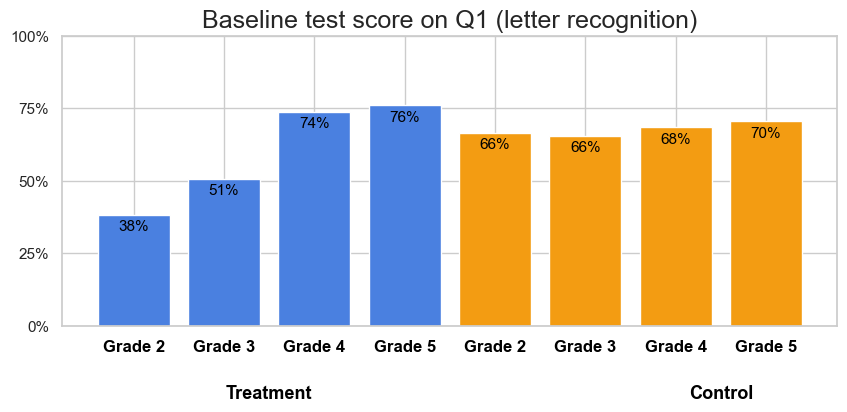

In [132]:
plot_question_chart(
    df=baseline_df,
    q_col='Hindi_Reading_1',
    q_max=5,
    title='Q1 (letter recognition)',
    stage_label='Baseline'
)

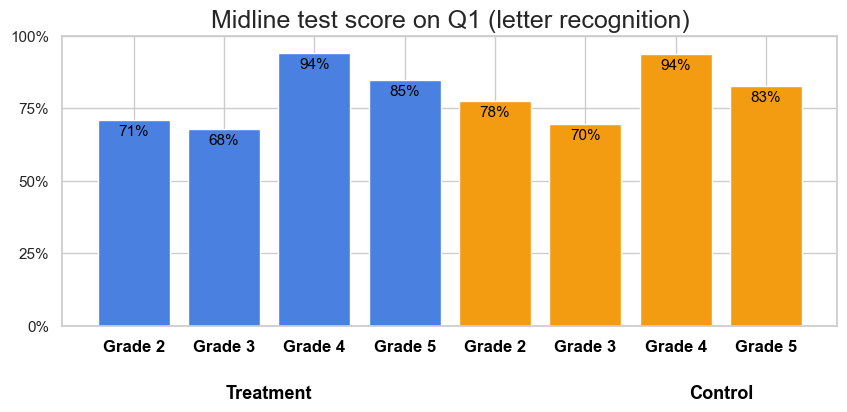

In [133]:
plot_question_chart(
    df=midline_df,
    q_col='Hindi_Reading_1',
    q_max=5,
    title='Q1 (letter recognition)',
    stage_label='Midline'
)

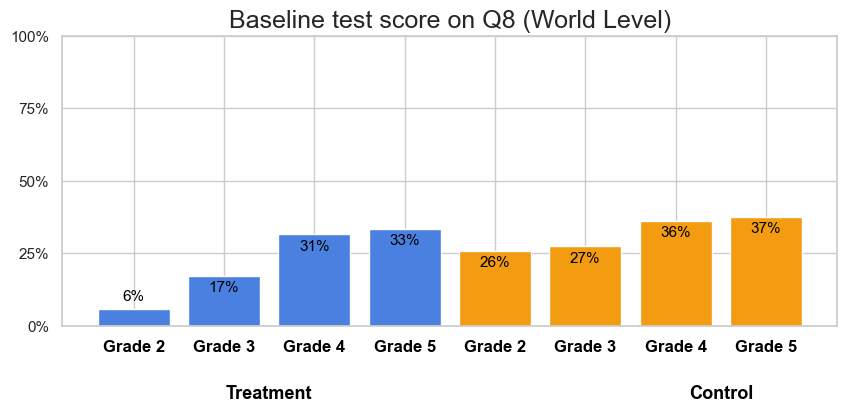

In [134]:
plot_question_chart(
    df=baseline_df,
    q_col='Hindi_Writing_1',
    q_max=6,
    title='Q8 (World Level)',
    stage_label='Baseline'
)

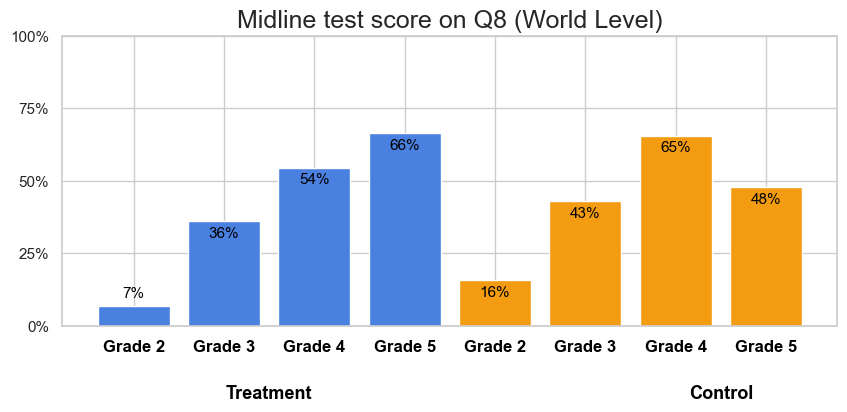

In [135]:
plot_question_chart(
    df=midline_df,
    q_col='Hindi_Writing_1',
    q_max=6,
    title='Q8 (World Level)',
    stage_label='Midline'
)

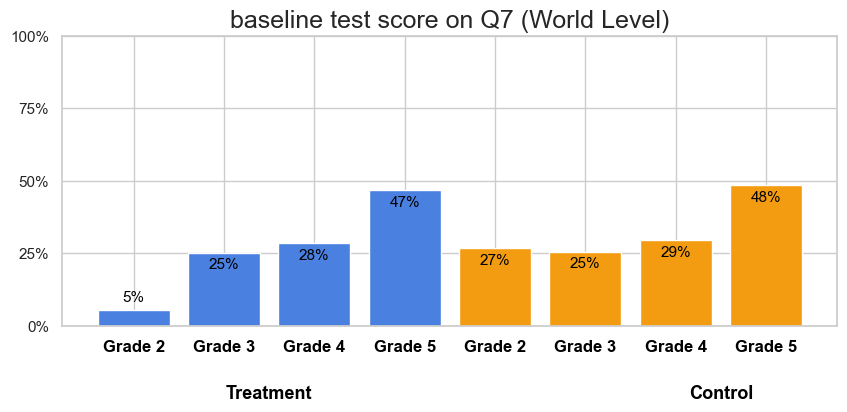

In [136]:
# 'Hindi_Writing_4': 4,

plot_question_chart(
    df=baseline_df,
    q_col='Hindi_Writing_3',
    q_max=4,
    title='Q7 (World Level)',
    stage_label='baseline'
)

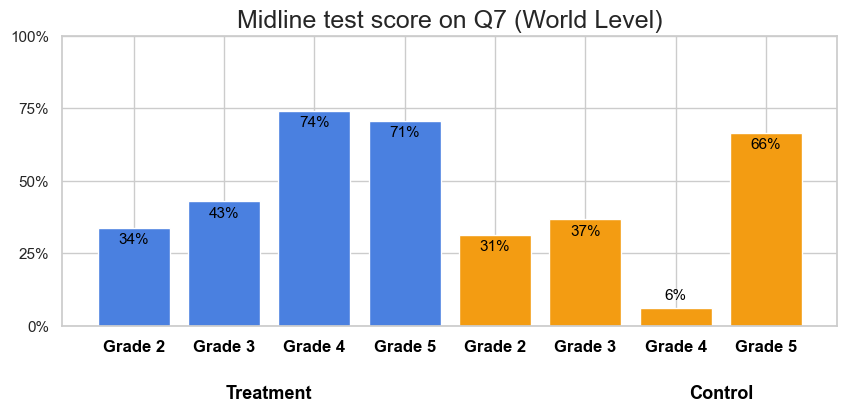

In [137]:
plot_question_chart(
    df=midline_df,
    q_col='Hindi_Writing_3',
    q_max=4,
    title='Q7 (World Level)',
    stage_label='Midline'
)

In [151]:
# plot_question_chart(
#     df=baseline_df,
#     q_col='Numeracy_Q1',
#     q_max=3,
#     title='Counting Object',
#     stage_label='Baseline'
# )

In [152]:
# plot_question_chart(
#     df=midline_df,
#     q_col='Numeracy_Q1',
#     q_max=3,
#     title='Counting Object',
#     stage_label='Midline'
# )

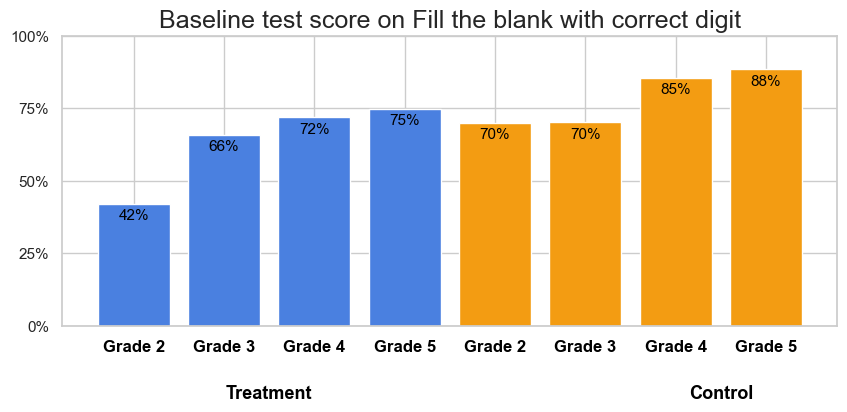

In [138]:
# # 'Numeracy_Q1': 3,

plot_question_chart(
    df=baseline_df,
    q_col='Numeracy_Q2',
    q_max=3,
    title='Fill the blank with correct digit',
    stage_label='Baseline'
)

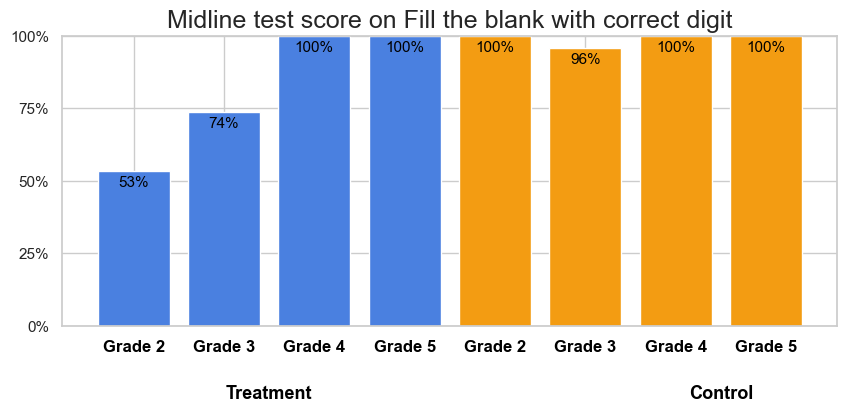

In [139]:
plot_question_chart(
    df=midline_df,
    q_col='Numeracy_Q2',
    q_max=3,
    title='Fill the blank with correct digit',
    stage_label='Midline'

)    

In [85]:
q_col = 'Hindi_Writing_3'   # <-- change to your question

temp = midline_df[
    midline_df['Group'].isin(['Treatment', 'Control']) &
    midline_df['Grade'].isin([2, 3, 4, 5])
].copy()

temp[q_col] = pd.to_numeric(temp[q_col], errors='coerce')

# Student count per group & grade
count_check = temp.groupby(['Group', 'Grade'])[q_col].count().reset_index(name='student_count')

print(count_check)

Empty DataFrame
Columns: [Group, Grade, student_count]
Index: []


In [86]:
missing_check = temp.groupby(['Group', 'Grade'])[q_col].apply(lambda x: x.isna().sum()).reset_index(name='missing_count')

print(missing_check)

Empty DataFrame
Columns: [Group, Grade, missing_count]
Index: []


In [87]:
school_check = (
    temp.groupby(['Group', 'Grade', 'School_Name'])[q_col]
    .mean()
    .reset_index()
)

print(school_check.sort_values(['Group', 'Grade', q_col]))

Empty DataFrame
Columns: [Group, Grade, School_Name, Hindi_Writing_3]
Index: []


In [121]:
print(temp[q_col].max())

nan
